In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [3]:
from inspect_ai.log import read_eval_log
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import concurrent.futures
import seaborn as sns



In [4]:
df_legal = pd.read_csv("adaptive_legal_results_4o_mini.csv")

In [5]:
df_legal['use_cot'] = df_legal['use_cot'].apply(lambda x: False if 'No CoT' in x else True)
df_legal


,Generator Model,use_cot,Accuracy Type,num_samples,n_positive_samples,Dataset,accuracy,eval_model
0,Meta-Llama-3.1-405B,True,(o1 judge),18,2,LegalBench,0.166667,gpt-4o-mini
1,Meta-Llama-3.1-405B,False,(no judge),30,2,LegalBench,0.310345,gpt-4o-mini
2,Meta-Llama-3.1-405B,False,(no judge),25,2,LegalBench,0.416667,gpt-4o-mini
3,Meta-Llama-3.1-405B,False,(o1 judge),20,2,LegalBench,0.350000,gpt-4o-mini
4,Meta-Llama-3.1-405B,True,(no judge),25,2,LegalBench,0.240000,gpt-4o-mini
5,Meta-Llama-3.1-405B,True,(no judge),30,2,LegalBench,0.466667,gpt-4o-mini
6,claude-3-5-sonnet,False,(no judge),25,2,LegalBench,0.120000,gpt-4o-mini
7,claude-3-5-sonnet,True,(no judge),25,2,LegalBench,0.240000,gpt-4o-mini
8,claude-3-5-sonnet,False,(o1 judge),23,2,LegalBench,0.130435,gpt-4o-mini
9,claude-3-5-sonnet,True,(no judge),50,2,LegalBench,0.023810,gpt-4o-mini


In [6]:
from inspect_ai.log import read_eval_log
import os
import numpy as np
from dataclasses import dataclass


sns.set_style("white")

@dataclass(frozen=True)
class AdaptiveLogKey:
    eval_model_name: str
    generator_model_name: str
    n_positive_samples: int
    n_negative_samples: int
    use_cot_generator: bool
    randomize_sampling: bool
    use_o1_judge: bool
        
@dataclass
class AdaptiveLogValue:
    log_path: str
    accuracy: float
    total_samples: int
    original_accuracy: float
    original_log_model: str
    accuracy_with_judge: float = None
    total_samples_with_judge: int = None  # Added to store total_samples_with_judge

# Set the base directories where your logs are stored
log_base_dir = "/Users/davisbrown/inspect_attacks/legal_experiment_logs"
base_dirs = ["/Users/davisbrown/inspect_attacks/legal_experiment_logs", "/Users/davisbrown/inspect_attacks/logs"]

# Get all log directories that contain the initial aggregated legalbench run
initial_logs_legal = {}
for d in os.listdir(log_base_dir):
    if "initial" in d:
        log_path = os.path.join(log_base_dir, d)
        log = read_eval_log(log_path)
        # Compute initial accuracy
        initial_logs_legal[log.eval.model] = AdaptiveLogValue(
            log_path=log_path,
            accuracy=log.results.metrics['accuracy'].value,
            total_samples=log.results.total_samples,
            original_accuracy=log.results.metrics['accuracy'].value,
            original_log_model=log.eval.model
        )

The 'metrics' field is deprecated. Access metrics through 'scorers' instead.


In [7]:
# Set the base directory where your logs are stored
from inspect_ai.log import list_eval_logs


log_base_dir = "../new_logs"

# Get all log directories that contain the adaptive_truthfulqa logs
log_dirs = [
    os.path.join(log_base_dir, d)
    for d in os.listdir(log_base_dir)
    if d.startswith("initial_adaptive_truthfulqa_log")
]

# Initialize a list to collect data
data = []

for log_dir in log_dirs:
    # Get all log files in the directory
    log_files = list_eval_logs(log_dir)

    for log_file in log_files:
        # Read the log file
        eval_log = read_eval_log(log_file)

        if eval_log.status == "success":
            # Try to extract parameters from eval_log
            try:
                task_parameters = eval_log.eval.task_args
            except AttributeError:
                task_parameters = {}

            # Extract the parameters we need
            eval_model_name = task_parameters.get("eval_model_name", "unknown")
            generator_model_name = task_parameters.get("generator_model_name", "unknown")
            n_positive_samples = task_parameters.get("n_positive_samples", 0)
            n_negative_samples = task_parameters.get("n_negative_samples", 0)
            use_cot = task_parameters.get("use_cot", False)

            # Compute accuracy
            total_samples = 0
            correct_samples = 0
            for sample in eval_log.samples:
                # Check if 'scores' field is available
                if sample.scores and sample.scores['adaptive_truthfulqa_scorer'].value in {"C", "I"}:
                    total_samples += 1
                    if sample.scores['adaptive_truthfulqa_scorer'].value == "C":
                        correct_samples += 1
            if total_samples == 0:
                continue  # Skip if no valid samples
            accuracy = correct_samples / total_samples

            # Collect data
            data.append({
                "eval_model": eval_model_name,
                "generator_model": generator_model_name,
                "n_positive_samples": n_positive_samples,
                "n_negative_samples": n_negative_samples,
                "use_cot": "CoT" if use_cot else "No CoT",
                "accuracy": accuracy,
            })


In [8]:
# df_truthfulqa = pd.read_csv("../adaptive_truthfulqa_results.csv")
df_truthfulqa = pd.DataFrame(data)
# rename generator_model to Generator Model
df_truthfulqa = df_truthfulqa.rename(columns={"generator_model": "Generator Model"})
# very every item in Generator Model column
df_truthfulqa['Generator Model'] = df_truthfulqa['Generator Model'].apply(lambda x: x.split('/')[-1])
# do the same for eval_model
df_truthfulqa['eval_model'] = df_truthfulqa['eval_model'].apply(lambda x: x.split('/')[-1])
# remove all rows where Generator Model is not in ['gpt-4o-mini', 'gpt-4o', 'Meta-Llama-3.1-405B-Instruct-Turbo', 'claude-3-5-sonnet-20240620']
df_truthfulqa = df_truthfulqa[df_truthfulqa['Generator Model'].isin(['gpt-4o-mini', 'gpt-4o', 'Meta-Llama-3.1-405B-Instruct-Turbo', 'claude-3-5-sonnet-20240620'])]
# change Meta-Llama-3.1-405B-Instruct-Turbo to Meta-Llama-3.1-405B
df_truthfulqa['Generator Model'] = df_truthfulqa['Generator Model'].apply(lambda x: 'Meta-Llama-3.1-405B' if 'Meta-Llama-3.1-405B-Instruct-Turbo' in x else x)
df_truthfulqa['Generator Model'] = df_truthfulqa['Generator Model'].apply(lambda x: 'claude-3-5-sonnet' if 'claude' in x else x)

# restrict to eval model gpt-4o
df_truthfulqa = df_truthfulqa[df_truthfulqa['eval_model'] == 'gpt-4o-mini']
# print(df_truthfulqa)
df_truthfulqa = df_truthfulqa[(df_truthfulqa['n_positive_samples'] == 2) | (df_truthfulqa['n_positive_samples'] == 4) | (df_truthfulqa['n_positive_samples'] == 1)]
df_truthfulqa['use_cot'] = df_truthfulqa['use_cot'].apply(lambda x: False if 'No CoT' in x else True)
df_truthfulqa["Dataset"] = "TruthfulQA"
df_truthfulqa


,eval_model,Generator Model,n_positive_samples,n_negative_samples,use_cot,accuracy,Dataset
0,gpt-4o-mini,Meta-Llama-3.1-405B,1,8,True,0.666667,TruthfulQA
1,gpt-4o-mini,Meta-Llama-3.1-405B,1,8,False,0.566667,TruthfulQA
26,gpt-4o-mini,gpt-4o-mini,4,16,True,0.800000,TruthfulQA
27,gpt-4o-mini,gpt-4o-mini,4,16,False,0.733333,TruthfulQA
28,gpt-4o-mini,gpt-4o-mini,4,8,True,0.933333,TruthfulQA
29,gpt-4o-mini,gpt-4o-mini,4,8,False,0.833333,TruthfulQA
30,gpt-4o-mini,gpt-4o-mini,4,4,True,0.833333,TruthfulQA
31,gpt-4o-mini,gpt-4o-mini,4,4,False,0.866667,TruthfulQA
32,gpt-4o-mini,gpt-4o-mini,2,16,True,0.733333,TruthfulQA
33,gpt-4o-mini,gpt-4o-mini,2,16,False,0.800000,TruthfulQA


In [9]:
df_legal.head()

,Generator Model,use_cot,Accuracy Type,num_samples,n_positive_samples,Dataset,accuracy,eval_model
0,Meta-Llama-3.1-405B,True,(o1 judge),18,2,LegalBench,0.166667,gpt-4o-mini
1,Meta-Llama-3.1-405B,False,(no judge),30,2,LegalBench,0.310345,gpt-4o-mini
2,Meta-Llama-3.1-405B,False,(no judge),25,2,LegalBench,0.416667,gpt-4o-mini
3,Meta-Llama-3.1-405B,False,(o1 judge),20,2,LegalBench,0.350000,gpt-4o-mini
4,Meta-Llama-3.1-405B,True,(no judge),25,2,LegalBench,0.240000,gpt-4o-mini


In [10]:
# combine df_legal and df_truthfulqa
df_combined = pd.concat([df_legal, df_truthfulqa])
# remove the columns num_samples, Category, Accuracy Type
df_combined = df_combined.drop(columns=["num_samples", "Accuracy Type", "n_positive_samples", "n_negative_samples"])
df_combined

,Generator Model,use_cot,Dataset,accuracy,eval_model
0,Meta-Llama-3.1-405B,True,LegalBench,0.166667,gpt-4o-mini
1,Meta-Llama-3.1-405B,False,LegalBench,0.310345,gpt-4o-mini
2,Meta-Llama-3.1-405B,False,LegalBench,0.416667,gpt-4o-mini
3,Meta-Llama-3.1-405B,False,LegalBench,0.350000,gpt-4o-mini
4,Meta-Llama-3.1-405B,True,LegalBench,0.240000,gpt-4o-mini
5,Meta-Llama-3.1-405B,True,LegalBench,0.466667,gpt-4o-mini
6,claude-3-5-sonnet,False,LegalBench,0.120000,gpt-4o-mini
7,claude-3-5-sonnet,True,LegalBench,0.240000,gpt-4o-mini
8,claude-3-5-sonnet,False,LegalBench,0.130435,gpt-4o-mini
9,claude-3-5-sonnet,True,LegalBench,0.023810,gpt-4o-mini


In [11]:
from inspect_ai.log import read_eval_log
import os
# grab initial log path for truthfulqa

initial_logs_truthfulqa = {}
eval_model = "openai/gpt-4o-mini"
log_dir = f"../new_logs/initial_truthfulqa_log_{eval_model.replace('/', '_')}"
if os.path.exists(log_dir):
    # check if any json exists in log_dir
    json_files = [f for f in os.listdir(log_dir) if f.endswith('.json')]
else:
    json_files = []

if json_files:
    try:
        initial_log_path = os.path.join(log_dir, max(
            json_files,
            key=lambda x: os.path.getctime(os.path.join(log_dir, x))
        ))
        initial_log = read_eval_log(initial_log_path)
        initial_logs_truthfulqa[eval_model] = AdaptiveLogValue(
            log_path=initial_log_path,
            accuracy=initial_log.results.metrics['accuracy'].value,
            total_samples=initial_log.results.total_samples,
            original_accuracy=initial_log.results.metrics['accuracy'].value,
            original_log_model=initial_log.eval.model
        )
    except Exception as e:
        print(f"An error occurred while retrieving the latest JSON file: {e}")
        # Handle the error as needed, possibly continue or exit

initial_accuracy_truthfulqa = initial_logs_truthfulqa[eval_model].accuracy

In [12]:
df_legal

,Generator Model,use_cot,Accuracy Type,num_samples,n_positive_samples,Dataset,accuracy,eval_model
0,Meta-Llama-3.1-405B,True,(o1 judge),18,2,LegalBench,0.166667,gpt-4o-mini
1,Meta-Llama-3.1-405B,False,(no judge),30,2,LegalBench,0.310345,gpt-4o-mini
2,Meta-Llama-3.1-405B,False,(no judge),25,2,LegalBench,0.416667,gpt-4o-mini
3,Meta-Llama-3.1-405B,False,(o1 judge),20,2,LegalBench,0.350000,gpt-4o-mini
4,Meta-Llama-3.1-405B,True,(no judge),25,2,LegalBench,0.240000,gpt-4o-mini
5,Meta-Llama-3.1-405B,True,(no judge),30,2,LegalBench,0.466667,gpt-4o-mini
6,claude-3-5-sonnet,False,(no judge),25,2,LegalBench,0.120000,gpt-4o-mini
7,claude-3-5-sonnet,True,(no judge),25,2,LegalBench,0.240000,gpt-4o-mini
8,claude-3-5-sonnet,False,(o1 judge),23,2,LegalBench,0.130435,gpt-4o-mini
9,claude-3-5-sonnet,True,(no judge),50,2,LegalBench,0.023810,gpt-4o-mini


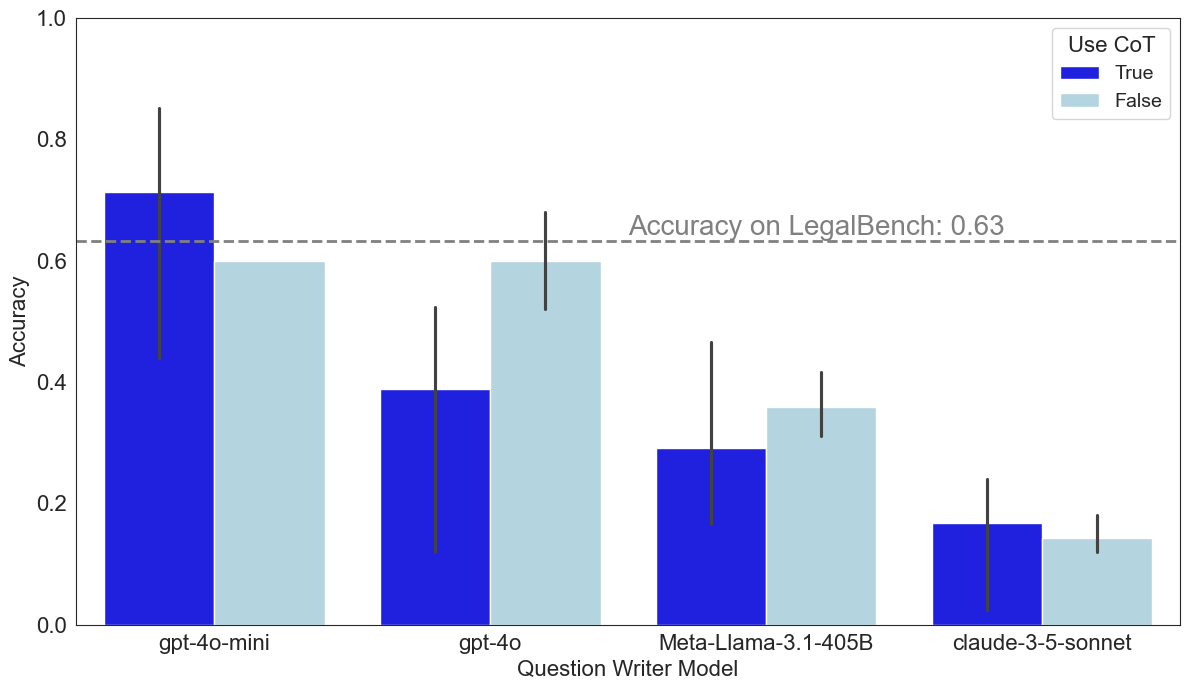

In [13]:
import numpy as np


eval_model_name = "openai/gpt-4o-mini"
generator_models = ["Meta-Llama-3.1-405B", "gpt-4o"] # df['Generator Model'].unique()
initial_accuracy_legal = initial_logs_legal[eval_model_name].accuracy

# Set the seaborn style to 'white'
sns.set_style("white")

# Plotting the data with four bars for each generator model
plt.figure(figsize=(12, 7))

# Define custom color palette
palette = {
    False: 'lightblue',
    True: 'blue',
}
# Create the bar plot
sns.barplot(
    data=df_legal,
    x='Generator Model',
    y='accuracy',
    hue='use_cot',
    order=['gpt-4o-mini', 'gpt-4o', 'Meta-Llama-3.1-405B', 'claude-3-5-sonnet'],
    hue_order=[True, False],
    palette=palette
)

# Adjust labels and title
plt.xlabel('Question Writer Model', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
# plt.title(f'Adaptive evaluation (LegalBench)for {eval_model_name.split("/")[-1]}', fontsize=22)

# Increase fontsize of labels and ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Plot the baseline performance as a dashed horizontal line
plt.axhline(y=initial_accuracy_legal, color='gray', linestyle='--', linewidth=2)

# Annotate the accuracy value above the line
plt.text(1.5, initial_accuracy_legal + 0.01, f'Accuracy on LegalBench: {initial_accuracy_legal:.2f}', color='gray', fontsize=20)

plt.ylim(0, 1)
plt.legend(title='Use CoT', title_fontsize=16, fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
initial_logs_truthfulqa.keys()

dict_keys(['openai/gpt-4o-mini'])

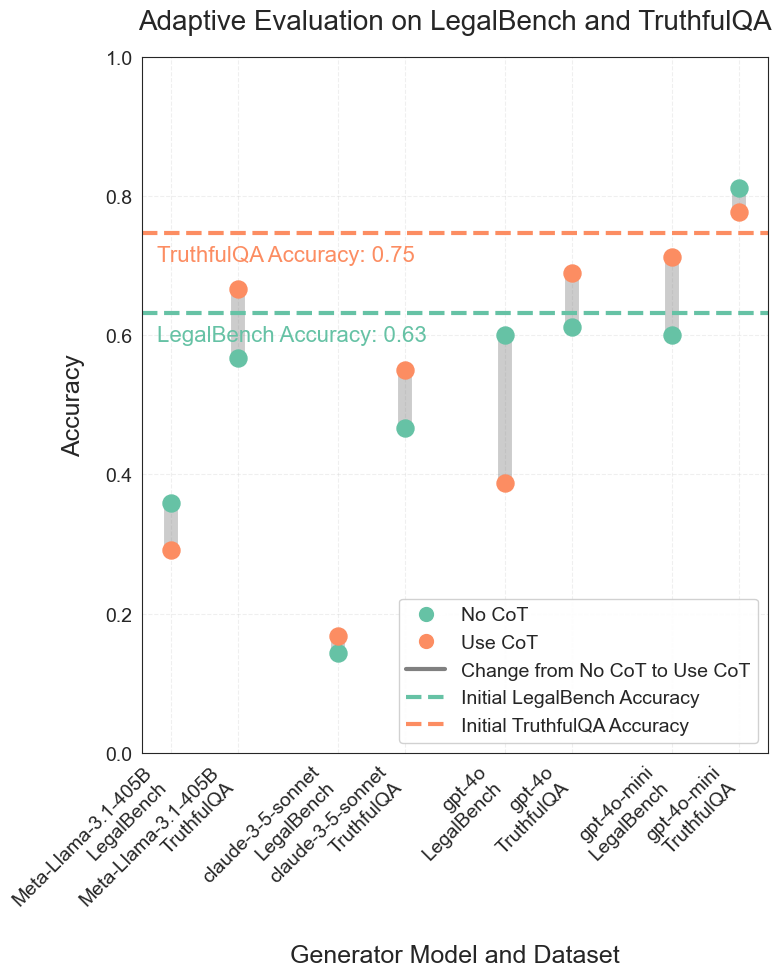

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Assuming df_combined is already available
# First, group the data
grouped = df_combined.groupby(['Generator Model', 'Dataset', 'use_cot'])['accuracy'].mean().reset_index()
# Pivot the data to have 'use_cot' as separate columns for dumbbell plotting
pivot_df = grouped.pivot_table(
    index=['Generator Model', 'Dataset'],
    columns='use_cot',
    values='accuracy'
).reset_index()

# Replace NaN with 0
pivot_df = pivot_df.fillna(0)

# Rename columns for clarity
pivot_df.columns.name = None
pivot_df = pivot_df.rename(columns={False: 'No CoT', True: 'Use CoT'})

# Define colors using a Seaborn palette
palette = sns.color_palette("Set2", 2)
color_no_cot = palette[0]
color_use_cot = palette[1]

# Assign positions for each Generator Model and Dataset combination
generator_models = pivot_df['Generator Model'].unique()
x_labels = []
x_pos = []
pos_dict = {}

current_pos = 0
for model in generator_models:
    datasets = pivot_df[pivot_df['Generator Model'] == model]['Dataset'].unique()
    for ds in datasets:
        x_labels.append(f"{model}\n{ds}")
        pos_dict[(model, ds)] = current_pos
        x_pos.append(current_pos)
        current_pos += 1
    # Add a gap between different models
    current_pos += 0.5

# Create the dumbbell plot with larger figure size
plt.figure(figsize=(8, 10))
ax = plt.gca()

# Set larger font sizes globally
plt.rcParams.update({'font.size': 14})

for idx, row in pivot_df.iterrows():
    ds = row['Dataset']
    model = row['Generator Model']
    xpos = pos_dict[(model, ds)]
    y_no_cot = row['No CoT']
    y_use_cot = row['Use CoT']
    
    # Plot the line between No CoT and Use CoT
    ax.plot([xpos, xpos], [y_no_cot, y_use_cot], color='gray', linewidth=10, zorder=1, alpha=0.4)
    
    # Plot the No CoT point with larger markers
    ax.scatter(xpos, y_no_cot, color=color_no_cot, s=150, zorder=2, label='No CoT' if idx == 0 else "")
    
    # Plot the Use CoT point with larger markers
    ax.scatter(xpos, y_use_cot, color=color_use_cot, s=150, zorder=2, label='Use CoT' if idx == 0 else "")

# Set x-axis labels with larger font
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=16)

# Set labels and title with larger fonts
ax.set_ylabel('Accuracy', fontsize=18, labelpad=15)
ax.set_xlabel('Generator Model and Dataset', fontsize=18, labelpad=15)
ax.set_title('Adaptive Evaluation on LegalBench and TruthfulQA', fontsize=20, pad=20)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=14)

# Plot initial accuracies as horizontal lines with increased width
ax.axhline(
    y=initial_accuracy_legal,
    color=color_no_cot,
    linestyle='--',
    linewidth=3,
    label='Initial LegalBench Accuracy'
)
ax.text(
    -0.2,
    initial_accuracy_legal - 0.04,
    f'LegalBench Accuracy: {initial_accuracy_legal:.2f}',
    color=color_no_cot,
    fontsize=16
)

ax.axhline(
    y=initial_accuracy_truthfulqa,
    color=color_use_cot,
    linestyle='--',
    linewidth=3,
    label='Initial TruthfulQA Accuracy'
)
ax.text(
    -0.2,
    initial_accuracy_truthfulqa - 0.04,
    f'TruthfulQA Accuracy: {initial_accuracy_truthfulqa:.2f}',
    color=color_use_cot,
    fontsize=16
)

# Create custom legend with larger elements
custom_lines = [
    Line2D([0], [0], marker='o', color='w', label='No CoT',
           markerfacecolor=color_no_cot, markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Use CoT',
           markerfacecolor=color_use_cot, markersize=12),
    Line2D([0], [0], color='gray', lw=3, label='Change from No CoT to Use CoT'),
    Line2D([0], [0], color=color_no_cot, lw=3, linestyle='--', label='Initial LegalBench Accuracy'),
    Line2D([0], [0], color=color_use_cot, lw=3, linestyle='--', label='Initial TruthfulQA Accuracy')
]
ax.legend(handles=custom_lines, loc='lower right', fontsize=14, framealpha=0.9)

# Add grid for better readability
ax.grid(True, linestyle='--', alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
df_combined[df_combined['Dataset'] == 'LegalBench']
pivot_df

,Generator Model,Dataset,No CoT,Use CoT
0,Meta-Llama-3.1-405B,LegalBench,0.359004,0.291111
1,Meta-Llama-3.1-405B,TruthfulQA,0.566667,0.666667
2,claude-3-5-sonnet,LegalBench,0.143478,0.167302
3,claude-3-5-sonnet,TruthfulQA,0.466667,0.550000
4,gpt-4o,LegalBench,0.600000,0.387937
5,gpt-4o,TruthfulQA,0.611111,0.688889
6,gpt-4o-mini,LegalBench,0.600000,0.713083
7,gpt-4o-mini,TruthfulQA,0.811111,0.777778


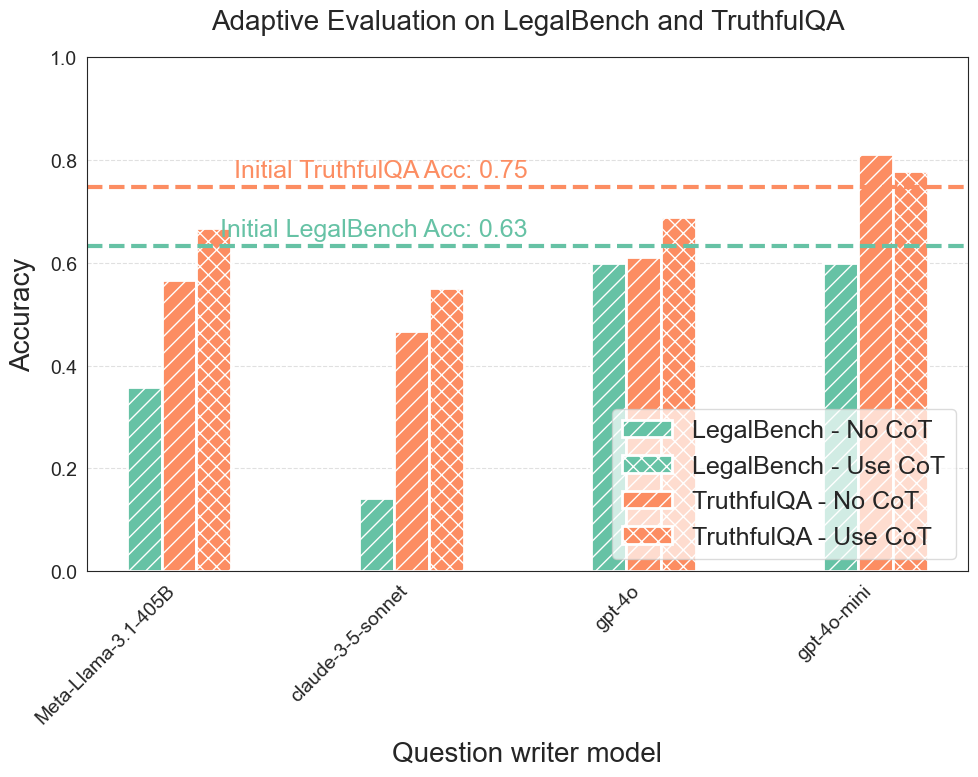

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from itertools import product

# Assuming df_combined is already available
# First, group the data
grouped = df_combined.groupby(['Generator Model', 'Dataset', 'use_cot'])['accuracy'].mean().reset_index()

# Pivot the data to have 'use_cot' as separate columns for grouped bar plotting
pivot_df = grouped.pivot_table(
    index=['Generator Model', 'Dataset'],
    columns='use_cot',
    values='accuracy'
).reset_index()

# Rename columns for clarity
pivot_df.columns.name = None
pivot_df = pivot_df.rename(columns={False: 'No CoT', True: 'Use CoT'})

# Define base colors for each Dataset using Seaborn's default palette
datasets = pivot_df['Dataset'].unique()
base_palette = sns.color_palette("Set2", len(datasets))
dataset_colors = {dataset: base_palette[i] for i, dataset in enumerate(datasets)}

# Assign hatch patterns for CoT conditions
cot_patterns = {'No CoT': '//', 'Use CoT': 'xx'}

# Assign positions for each Generator Model
generator_models = pivot_df['Generator Model'].unique()
x_labels = list(generator_models)
x_pos = np.arange(len(x_labels))
width = 0.15  # Width of each bar

# Ensure all combinations of Generator Model and Dataset are present
all_combinations = pd.DataFrame(list(product(generator_models, datasets)), columns=['Generator Model', 'Dataset'])
pivot_df = all_combinations.merge(pivot_df, on=['Generator Model', 'Dataset'], how='left').fillna(0)

# Initialize plot
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Plot bars
for idx, dataset in enumerate(datasets):
    for jdx, cot_condition in enumerate(['No CoT', 'Use CoT']):
        # Calculate the offset for grouped bars
        offset = (idx - len(datasets)/2) * width + (jdx * width)
        # Extract accuracy values
        accuracies = pivot_df[pivot_df['Dataset'] == dataset][cot_condition].values
        # Plot bars
        ax.bar(x_pos + offset, accuracies,
               width=width,
               label=f'{dataset} - {cot_condition}' if idx == 0 else "",
               color=dataset_colors[dataset],
               hatch=cot_patterns[cot_condition],
               edgecolor='white',
               linewidth=2)  # Increased bar edge thickness

# Set x-axis labels with larger font
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=14)
ax.tick_params(axis='y', labelsize=14)  # Increased y-tick font size

# Set labels and title with larger fonts
ax.set_ylabel('Accuracy', fontsize=20, labelpad=10)
ax.set_xlabel('Question writer model', fontsize=20, labelpad=10)
ax.set_title('Adaptive Evaluation on LegalBench and TruthfulQA', fontsize=20, pad=20)

# Plot initial accuracies as horizontal lines
for dataset in datasets:
    if dataset == 'LegalBench':
        initial_accuracy = initial_accuracy_legal
    elif dataset == 'TruthfulQA':
        initial_accuracy = initial_accuracy_truthfulqa
    else:
        initial_accuracy = 0  # Default or handle accordingly
    ax.axhline(
        y=initial_accuracy,
        color=dataset_colors[dataset],
        linestyle='--',
        linewidth=3,  # Increased line thickness
        label=f'{dataset} Accuracy'
    )
    ax.text(
        1.5,
        initial_accuracy + 0.01,
        f'Initial {dataset} Acc: {initial_accuracy:.2f}',
        color=dataset_colors[dataset],
        fontsize=18,  # Increased font size
        va='bottom',
        ha='right'
    )

# Create custom legend with larger font
legend_elements = []
# Add Dataset and CoT condition combinations
for dataset in datasets:
    for cot_condition in ['No CoT', 'Use CoT']:
        legend_elements.append(Patch(facecolor=dataset_colors[dataset],
                                     hatch=cot_patterns[cot_condition],
                                     edgecolor='white',
                                     linewidth=2,  # Increased legend element thickness
                                     label=f'{dataset} - {cot_condition}'))
# Add initial accuracy lines
# for dataset in datasets:
#     legend_elements.append(Line2D([0], [0], color=dataset_colors[dataset], 
#                                 linestyle='--', 
#                                 linewidth=3,  # Increased legend line thickness
#                                 label=f'Initial {dataset} Accuracy'))

ax.legend(handles=legend_elements, loc='lower right', fontsize=18, framealpha=0.7)

# Add grid for better readability
ax.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [18]:
pivot_df

,Generator Model,Dataset,No CoT,Use CoT
0,Meta-Llama-3.1-405B,LegalBench,0.359004,0.291111
1,Meta-Llama-3.1-405B,TruthfulQA,0.566667,0.666667
2,claude-3-5-sonnet,LegalBench,0.143478,0.167302
3,claude-3-5-sonnet,TruthfulQA,0.466667,0.550000
4,gpt-4o,LegalBench,0.600000,0.387937
5,gpt-4o,TruthfulQA,0.611111,0.688889
6,gpt-4o-mini,LegalBench,0.600000,0.713083
7,gpt-4o-mini,TruthfulQA,0.811111,0.777778


In [19]:
df_melted

,Generator Model,Dataset,CoT,Performance
0,Llama-3.1-405B,LegalBench,No CoT,0.359004
1,Llama-3.1-405B,LegalBench,Use CoT,0.291111
2,Llama-3.1-405B,TruthfulQA,No CoT,0.566667
3,Llama-3.1-405B,TruthfulQA,Use CoT,0.666667
4,claude-3-5-sonnet,LegalBench,No CoT,0.143478
5,claude-3-5-sonnet,LegalBench,Use CoT,0.167302
6,claude-3-5-sonnet,TruthfulQA,No CoT,0.466667
7,claude-3-5-sonnet,TruthfulQA,Use CoT,0.550000
8,gpt-4o,LegalBench,No CoT,0.600000
9,gpt-4o,LegalBench,Use CoT,0.387937


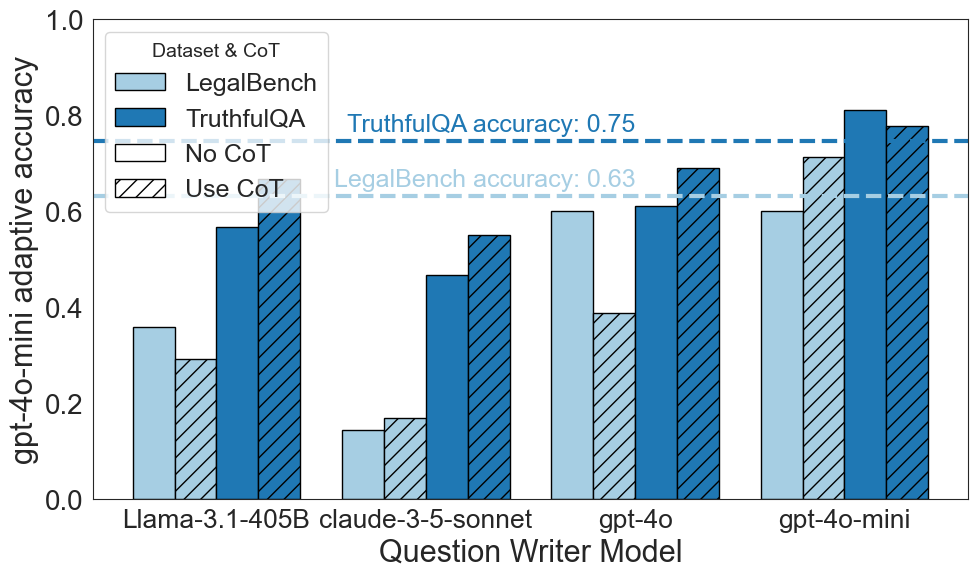

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Create the DataFrame with your data
data = {
    'Generator Model': [
        'Llama-3.1-405B', 'Llama-3.1-405B',
        'claude-3-5-sonnet', 'claude-3-5-sonnet',
        'gpt-4o', 'gpt-4o',
        'gpt-4o-mini', 'gpt-4o-mini'
    ],
    'Dataset': [
        'LegalBench', 'TruthfulQA',
        'LegalBench', 'TruthfulQA',
        'LegalBench', 'TruthfulQA',
        'LegalBench', 'TruthfulQA'
    ],
    'No CoT': [
        0.359004, 0.566667,
        0.143478, 0.466667,
        0.600000, 0.611111,
        0.600000, 0.811111
    ],
    'Use CoT': [
        0.291111, 0.666667,
        0.167302, 0.550000,
        0.387937, 0.688889,
        0.713083, 0.777778
    ]
}

df = pd.DataFrame(data)

# Melt the DataFrame to long format
df_melted = df.melt(
    id_vars=['Generator Model', 'Dataset'],
    value_vars=['No CoT', 'Use CoT'],
    var_name='CoT',
    value_name='Performance'
)

# Sort the DataFrame for consistent plotting
df_melted.sort_values(by=['Generator Model', 'Dataset', 'CoT'], inplace=True)
df_melted.reset_index(drop=True, inplace=True)

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Define positions
generator_models = df_melted['Generator Model'].unique()
datasets = df_melted['Dataset'].unique()
cots = df_melted['CoT'].unique()

num_datasets = len(datasets)
num_cots = len(cots)
num_models = len(generator_models)

total_width = 0.8  # Total width for all bars at one x position
bar_width = total_width / (num_datasets * num_cots)
x = np.arange(num_models)  # X positions for the generator models

# Create a color palette for datasets
palette = sns.color_palette('Paired', num_datasets)

# Initialize bar positions
offset = -total_width / 2 + bar_width / 2

for i, dataset in enumerate(datasets):
    for j, cot in enumerate(cots):
        # Filter data for each combination
        subset = df_melted[(df_melted['Dataset'] == dataset) & (df_melted['CoT'] == cot)]
        
        # Calculate positions for bars
        positions = x + offset + (i * num_cots + j) * bar_width
        
        # Plot bars
        bars = plt.bar(
            positions,
            subset['Performance'],
            bar_width,
            label=f'{dataset} {"CoT" if cot == "Use CoT" else ""}',
            color=palette[i],
            edgecolor='black',
            hatch='//' if cot == 'Use CoT' else ''
        )


# Plot initial accuracies as horizontal lines
for dataset in datasets:
    if dataset == 'LegalBench':
        initial_accuracy = initial_accuracy_legal
        color = palette[0]  # Use same color as LegalBench bars
    elif dataset == 'TruthfulQA':
        initial_accuracy = initial_accuracy_truthfulqa
        color = palette[1]  # Use same color as TruthfulQA bars
    else:
        initial_accuracy = 0  # Default or handle accordingly
        color = 'gray'
    plt.axhline(
        y=initial_accuracy,
        color=color,
        linestyle='--', 
        linewidth=3,  # Increased line thickness
        label=f'{dataset} Accuracy'
    )
    plt.text(
        2.0,
        initial_accuracy + 0.01,
        f'{dataset} accuracy: {initial_accuracy:.2f}',
        color=color,
        fontsize=18,  # Increased font size
        va='bottom',
        ha='right'
    )
        
# Set x-ticks and labels
plt.ylim(0, 1)
# set y tick size
plt.yticks(fontsize=20)
plt.xticks(x, generator_models, fontsize=19,)
plt.xlabel('Question Writer Model', fontsize=22)
plt.ylabel('gpt-4o-mini adaptive accuracy', fontsize=22)
# plt.title('Performance by Generator Model, Dataset, and Chain of Thought')

# Create custom legends
# Legend for Dataset
dataset_patches = [
    Patch(
        facecolor=palette[i],
        edgecolor='black',
        label=datasets[i]
    ) for i in range(num_datasets)
]

# Legend for CoT
hatch_patterns = {'No CoT': '', 'Use CoT': '//'}

cot_patches = [
    Patch(
        facecolor='white',
        hatch=hatch_patterns[cot],
        edgecolor='black',
        label=cot
    ) for cot in cots
]
plt.legend(handles=dataset_patches + cot_patches, title='Dataset & CoT', fontsize=18)
# plt.gca().add_artist(first_legend)

plt.tight_layout()
plt.savefig('combined-adaptive-plot-gpt-4o-mini.png', dpi=300)
plt.show()
